# Olist E-commerce — Análisis de Comportamiento de Usuarios

Análisis de cohortes, retención y funnel de conversión usando datos reales 
de Olist, el mayor e-commerce de Brasil (100k+ órdenes, 2016-2018).

## Objetivo
Identificar patrones de retención de clientes, revenue mensual 
y comportamiento de compra para generar insights accionables de negocio.

## Herramientas
- Python — Pandas, Matplotlib, Seaborn
- SQLite — análisis con SQL puro

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Ruta a los archivos
PATH = os.path.expanduser("~/Documents/olist_project/")

print("Librerías cargadas correctamente")
print(f"Ruta del proyecto: {PATH}")

Librerías cargadas correctamente
Ruta del proyecto: /Users/calderdavid_/Documents/olist_project/


In [2]:
# Cargar los datasets principales
orders = pd.read_csv(PATH + 'olist_orders_dataset.csv')
customers = pd.read_csv(PATH + 'olist_customers_dataset.csv')
payments = pd.read_csv(PATH + 'olist_order_payments_dataset.csv')

print(f"Orders: {orders.shape[0]:,} filas, {orders.shape[1]} columnas")
print(f"Customers: {customers.shape[0]:,} filas, {customers.shape[1]} columnas")
print(f"Payments: {payments.shape[0]:,} filas, {payments.shape[1]} columnas")

print("\nColumnas de Orders:")
print(orders.columns.tolist())

Orders: 99,441 filas, 8 columnas
Customers: 99,441 filas, 5 columnas
Payments: 103,886 filas, 5 columnas

Columnas de Orders:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


In [3]:
# Convertir fechas y limpiar datos
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

# Crear columnas de año y mes
orders['year'] = orders['order_purchase_timestamp'].dt.year
orders['month'] = orders['order_purchase_timestamp'].dt.month
orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

# Ver distribución de estados de órdenes
print("=== ESTADOS DE ÓRDENES ===")
print(orders['order_status'].value_counts())
print(f"\nRango de fechas: {orders['order_purchase_timestamp'].min().date()} → {orders['order_purchase_timestamp'].max().date()}")

=== ESTADOS DE ÓRDENES ===
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Rango de fechas: 2016-09-04 → 2018-10-17


In [4]:
# Unir orders con payments
df = orders.merge(payments, on='order_id', how='left')

# Filtrar solo órdenes entregadas
df_delivered = df[df['order_status'] == 'delivered'].copy()

# Revenue mensual
revenue_mensual = df_delivered.groupby('year_month')['payment_value'].sum().reset_index()
revenue_mensual.columns = ['year_month', 'revenue']
revenue_mensual['year_month_str'] = revenue_mensual['year_month'].astype(str)

print(f"Total revenue: R$ {df_delivered['payment_value'].sum():,.0f}")
print(f"Ticket promedio: R$ {df_delivered['payment_value'].mean():,.2f}")
print(f"\nTop 5 meses por revenue:")
print(revenue_mensual.nlargest(5, 'revenue')[['year_month_str', 'revenue']])

Total revenue: R$ 15,422,462
Ticket promedio: R$ 153.07

Top 5 meses por revenue:
   year_month_str     revenue
13        2017-11  1153528.05
18        2018-04  1132933.95
19        2018-05  1128836.69
17        2018-03  1120678.00
15        2018-01  1078606.86


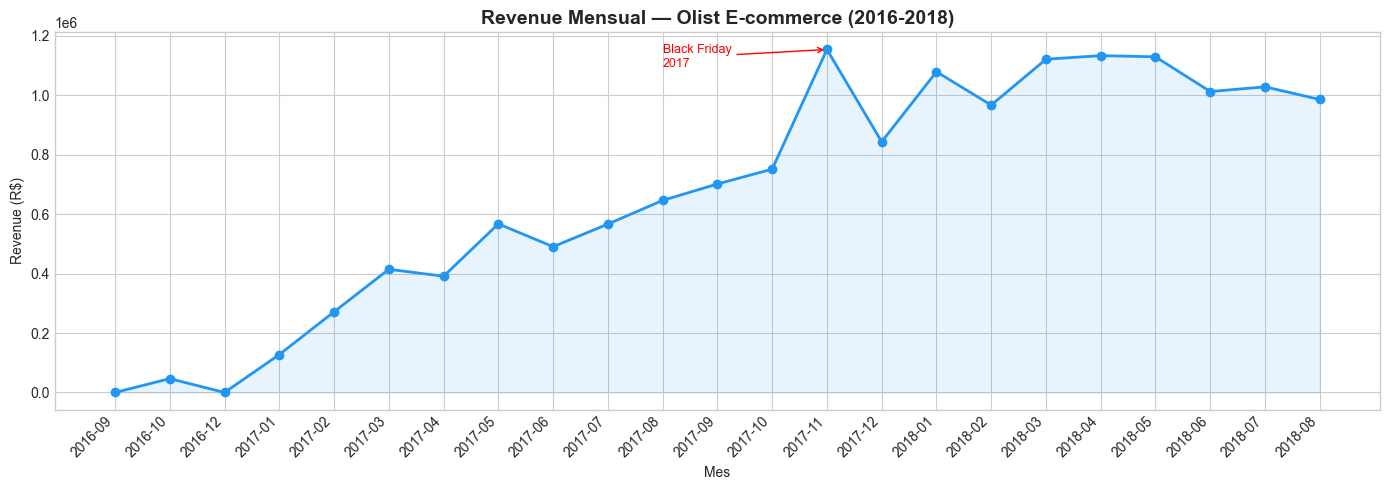

In [6]:
# Gráfico: Revenue mensual
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(revenue_mensual['year_month_str'], 
        revenue_mensual['revenue'], 
        marker='o', linewidth=2, color='#2196F3')

ax.fill_between(range(len(revenue_mensual)), 
                revenue_mensual['revenue'], 
                alpha=0.1, color='#2196F3')

# Marcar el mes peak
peak_idx = revenue_mensual['revenue'].idxmax()
ax.annotate('Black Friday\n2017', 
            xy=(peak_idx, revenue_mensual['revenue'].max()),
            xytext=(peak_idx - 3, revenue_mensual['revenue'].max() * 0.95),
            arrowprops=dict(arrowstyle='->', color='red'),
            color='red', fontsize=9)

ax.set_title('Revenue Mensual — Olist E-commerce (2016-2018)', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Mes')
ax.set_ylabel('Revenue (R$)')
ax.set_xticks(range(len(revenue_mensual)))
ax.set_xticklabels(revenue_mensual['year_month_str'], rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [7]:
# Análisis de cohortes
# Unir orders con customers
df_cohort = orders[orders['order_status'] == 'delivered'].merge(
    customers[['customer_id', 'customer_unique_id']], 
    on='customer_id', how='left'
)

# Primera compra de cada cliente
df_cohort['cohort_month'] = df_cohort.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M')

# Mes de la orden actual
df_cohort['order_month'] = df_cohort['order_purchase_timestamp'].dt.to_period('M')

# Índice de cohorte: meses desde la primera compra
df_cohort['cohort_index'] = (
    df_cohort['order_month'] - df_cohort['cohort_month']
).apply(lambda x: x.n)

print("Cohortes creadas correctamente")
print(f"Clientes únicos: {df_cohort['customer_unique_id'].nunique():,}")
print(f"\nMuestra de datos:")
print(df_cohort[['customer_unique_id', 'cohort_month', 'order_month', 'cohort_index']].head())

Cohortes creadas correctamente
Clientes únicos: 93,358

Muestra de datos:
                 customer_unique_id cohort_month order_month  cohort_index
0  7c396fd4830fd04220f754e42b4e5bff      2017-09     2017-10             1
1  af07308b275d755c9edb36a90c618231      2018-07     2018-07             0
2  3a653a41f6f9fc3d2a113cf8398680e8      2018-08     2018-08             0
3  7c142cf63193a1473d2e66489a9ae977      2017-11     2017-11             0
4  72632f0f9dd73dfee390c9b22eb56dd6      2018-02     2018-02             0


In [8]:
# Construir tabla de cohortes
cohort_data = df_cohort.groupby(['cohort_month', 'cohort_index'])['customer_unique_id'].nunique().reset_index()
cohort_data.columns = ['cohort_month', 'cohort_index', 'customers']

cohort_pivot = cohort_data.pivot_table(
    index='cohort_month', 
    columns='cohort_index', 
    values='customers'
)

# Calcular retention rate como porcentaje
cohort_size = cohort_pivot.iloc[:, 0]
retention = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100

# Mostrar solo primeros 12 meses y primeras 10 cohortes
retention_display = retention.iloc[:10, :8]

print("Tabla de retención (%):")
print(retention_display)

Tabla de retención (%):
cohort_index      0      1    2    3    4    5    6    7
cohort_month                                            
2016-09       100.0    NaN  NaN  NaN  NaN  NaN  NaN  NaN
2016-10       100.0    NaN  NaN  NaN  NaN  NaN  0.4  NaN
2016-12       100.0  100.0  NaN  NaN  NaN  NaN  NaN  NaN
2017-01       100.0    0.3  0.3  0.1  0.4  0.1  0.4  0.1
2017-02       100.0    0.2  0.3  0.1  0.4  0.1  0.2  0.2
2017-03       100.0    0.4  0.4  0.4  0.4  0.2  0.2  0.3
2017-04       100.0    0.6  0.2  0.2  0.3  0.3  0.4  0.3
2017-05       100.0    0.5  0.5  0.3  0.3  0.3  0.4  0.1
2017-06       100.0    0.5  0.4  0.4  0.3  0.4  0.4  0.2
2017-07       100.0    0.5  0.3  0.2  0.3  0.2  0.3  0.1


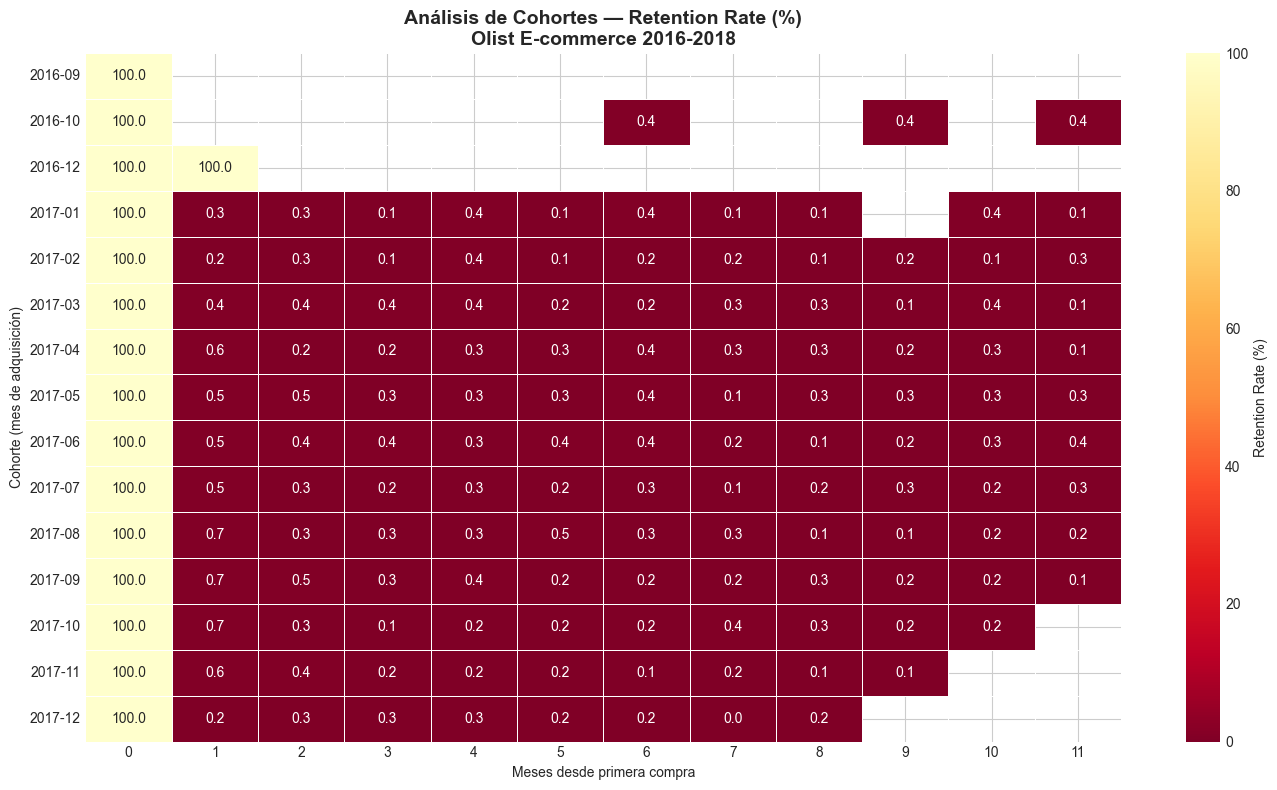

In [9]:
# Heatmap de cohortes
fig, ax = plt.subplots(figsize=(14, 8))

sns.heatmap(retention.iloc[:15, :12],
            annot=True,
            fmt='.1f',
            cmap='YlOrRd_r',
            ax=ax,
            linewidths=0.5,
            cbar_kws={'label': 'Retention Rate (%)'}
            )

ax.set_title('Análisis de Cohortes — Retention Rate (%)\nOlist E-commerce 2016-2018', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Meses desde primera compra')
ax.set_ylabel('Cohorte (mes de adquisición)')

plt.tight_layout()
plt.show()

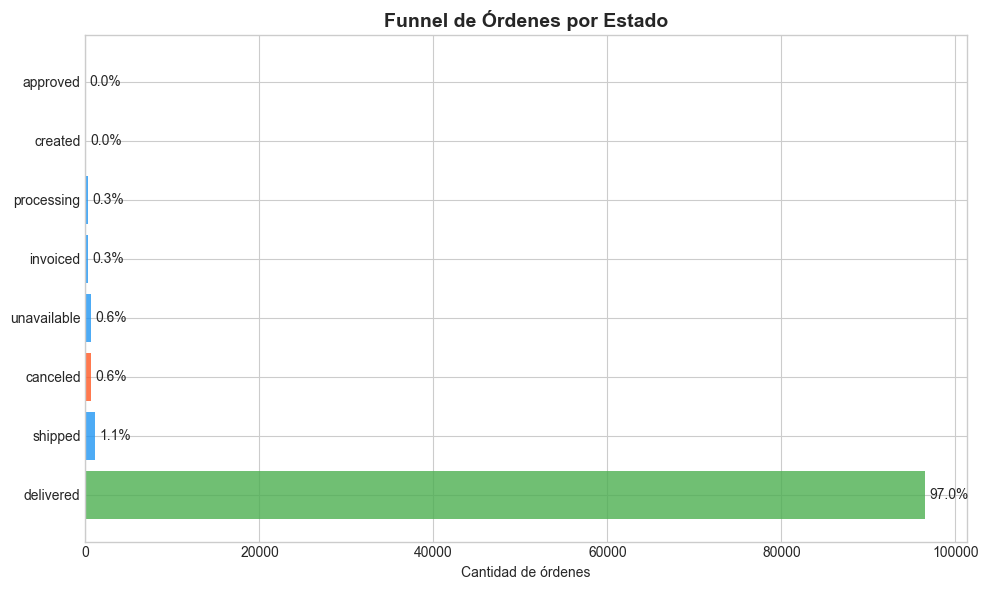


Resumen:
     status  count  percentage
  delivered  96478        97.0
    shipped   1107         1.1
   canceled    625         0.6
unavailable    609         0.6
   invoiced    314         0.3
 processing    301         0.3
    created      5         0.0
   approved      2         0.0


In [10]:
# Funnel de órdenes por estado
funnel = orders['order_status'].value_counts().reset_index()
funnel.columns = ['status', 'count']
funnel['percentage'] = (funnel['count'] / len(orders) * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 6))

colores = ['#4CAF50' if s == 'delivered' else '#FF5722' if s == 'canceled' else '#2196F3' 
           for s in funnel['status']]

bars = ax.barh(funnel['status'], funnel['count'], color=colores, alpha=0.8)

for bar, pct in zip(bars, funnel['percentage']):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=10)

ax.set_title('Funnel de Órdenes por Estado', fontsize=14, fontweight='bold')
ax.set_xlabel('Cantidad de órdenes')
plt.tight_layout()
plt.show()

print("\nResumen:")
print(funnel.to_string(index=False))

## Insights principales

### Revenue
- Revenue total del período: **R$15.4M**
- Ticket promedio: **R$153**
- Peak de ventas: **Noviembre 2017 (Black Friday)** con R$1.15M
- Crecimiento consistente de 2016 a 2018

### Retención de clientes
- Retención mes 1: **menos del 1%** en todas las cohortes
- Olist tiene un problema crítico de retención
- Casi ningún cliente realiza una segunda compra
- Recomendación: implementar programa de fidelización y email marketing post-compra

### Operaciones
- **97% de órdenes entregadas** exitosamente
- Solo **0.6% de cancelaciones** — operación muy eficiente
- 1.1% de órdenes aún